In [18]:
import pygeovision as pgv
from pathlib import Path

client = pgv.PyGeoVision()

BOUNDARY_PATH = "./data/accra_boundary.geojson"

aoi = client.boundary(
    "Accra Metropolitan District, Greater Accra Region, Ghana",
    output_path=BOUNDARY_PATH,
    reference_area_km2=139.0,
    raise_on_mismatch=False,
)
print(aoi.summary())

# 1. Search wide — enough candidates for select_covering_scenes to choose from
results = client.search(
    bbox=aoi.bbox,
    date_range=("2024-01-01", "2024-04-30"),
    providers=["element84"],
    cloud_cover_max=15,
    sort_by="cloud_cover",
    use_cache=False,
    max_results=50,
)
if not results:
    raise RuntimeError("No scenes found for Accra bbox — widen date_range or cloud_cover_max.")

# 2. Pick the fewest, lowest-cloud scenes that together cover the whole AOI
selected = client.select_covering_scenes(results, aoi.bbox, max_scenes=6)
print(f"Selected {len(selected)}/{len(results)} scenes to cover the AOI")

# 3. Download all selected scenes
downloads = client.download(
    selected, output_dir="./data/tiles",
    bands=["B02", "B03", "B04", "B08", "B11", "B12"],
)
failed = [d for d in downloads if not d.success or not d.path]
for f in failed:
    print(f"  FAILED: {f.scene_id} — {f.error or 'no error message'}")
succeeded = [d for d in downloads if d.success and d.path]
if not succeeded:
    raise RuntimeError("All scene downloads failed — see errors above.")
print(f"{len(succeeded)}/{len(downloads)} scenes downloaded successfully")

# 4. Reproject every tile to one common CRS before mosaicking
#    (Accra sits close to the 30N/31N UTM boundary — tiles can differ)
COMMON_CRS = "EPSG:32630"
reprojected_paths = [
    client._pgf_bridge.preprocess_reproject(str(d.path), crs=COMMON_CRS)
    for d in succeeded
]

# 5. Mosaic via the public, validated Preprocessor.mosaic() —
#    checks band-count/dtype consistency, no-ops on a single input
mosaic_path = client.preprocess.mosaic(
    reprojected_paths,
    output_path="./data/accra_mosaic.tif",
    method="first",
)
print(f"Mosaic written to: {mosaic_path}")

# 6. Prepare the mosaic for AI, clipped to the real boundary polygon
ready = client.prepare_for_ai(
    mosaic_path,
    model_type="foundation",
    output_path="./data/ready.tif",
    clip_geojson=BOUNDARY_PATH,
)

client.classification.land_cover(ready, output_path="./data/lc.tif")

01:13:17 INFO [      engine] PyGeoFetch ready


2026-07-30 01:13:17,840 [INFO] pygeofetch.core.engine: PyGeoFetch ready


01:13:17 INFO [      engine] PyGeoFetch ready


2026-07-30 01:13:17,841 [INFO] pygeofetch.core.engine: PyGeoFetch ready
2026-07-30 01:13:17,843 [INFO] pygeovision.data.pgf_bridge: PyGeoFetch v1.0 Python API active — using native search/download
2026-07-30 01:13:17,843 [INFO] pygeovision.data.pgf_bridge: PyGeoFetch v2.0 processing engine detected — using native preprocessing
2026-07-30 01:13:18,314 [WARNING] pygeovision.data.boundary: Fetched boundary area (23.7 km²) deviates 83% from the known reference (139.0 km²) for 'Accra Metropolitan District, Greater Accra Region, Ghana'. Two likely causes: (1) the query resolved to the wrong OSM entity — check osm_type='relation', category='boundary', display_name='Accra Metropolitan District, Greater Accra Region, Ghana' against what you expect; or (2) this is the *right* entity, but OpenStreetMap's community-digitized boundary for it is measurably smaller/larger than the official statistic — a real, known limitation for many regions (especially outside Europe/North America), not necessarily

AOI: Accra Metropolitan District, Greater Accra Region, Ghana
  Query               : Accra Metropolitan District, Greater Accra Region, Ghana
  OSM type / class    : relation / boundary
  BBox (WGS84)        : (-0.2555, 5.5228, -0.2009, 5.5994)
  Area (fetched)      : 23.7 km²
  UTM zone (auto)     : EPSG:32630
  Reference area check: 139.0 km² (82.9% deviation) — ✗ FAILED
  ⚠ Fetched boundary area (23.7 km²) deviates 83% from the known reference (139.0 km²) for 'Accra Metropolitan District, Greater Accra Region, Ghana'. Two likely causes: (1) the query resolved to the wrong OSM entity — check osm_type='relation', category='boundary', display_name='Accra Metropolitan District, Greater Accra Region, Ghana' against what you expect; or (2) this is the *right* entity, but OpenStreetMap's community-digitized boundary for it is measurably smaller/larger than the official statistic — a real, known limitation for many regions (especially outside Europe/North America), not necessarily an error

...

01:16:23 INFO [preprocessor] Reprojected → EPSG:32630 → data/tiles/aws_earth/AOT_reproj_EPSG_32630.tif


2026-07-30 01:16:23,673 [INFO] pygeofetch.processing.preprocessor: Reprojected → EPSG:32630 → data/tiles/aws_earth/AOT_reproj_EPSG_32630.tif
2026-07-30 01:16:23,959 [INFO] pygeovision.preprocess.core: Mosaicked 6 rasters → ./data/accra_mosaic.tif (1830x1830 px, 1 band(s), float32)
2026-07-30 01:16:24,112 [WARNING] pygeovision.data.validator: validate_for_inference: 1 bands present, model_type='foundation' needs ≥ 3. Repeating bands cyclically.


Mosaic written to: ./data/accra_mosaic.tif


2026-07-30 01:16:34,009 [WARNING] rasterio._env: CPLE_IllegalArg in lc.tif: BLOCKXSIZE can only be used with TILED=YES
ERROR 10: Pointer 'hObject' is NULL in 'GDALGetMetadata'.

ERROR 10: Pointer 'hObject' is NULL in 'GDALGetMetadata'.

ERROR 10: Pointer 'hObject' is NULL in 'GDALGetMetadata'.

2026-07-30 01:16:34,069 [ERROR] pygeovision.labeling.landcover: Merge failed: 'Polygon' object has no attribute 'to_json'
2026-07-30 01:16:34,079 [INFO] rasterio._env: GDAL signalled an error: err_no=4, msg='None: No such file or directory'


{'success': False,
 'output_path': 'data/lc.tif',
 'year': 2021,
 'classes_found': {},
 'class_map': {10: 'Tree cover',
  20: 'Shrubland',
  30: 'Grassland',
  40: 'Cropland',
  50: 'Built-up',
  60: 'Bare/sparse vegetation',
  70: 'Snow and ice',
  80: 'Permanent water bodies',
  90: 'Herbaceous wetland',
  95: 'Mangroves',
  100: 'Moss and lichen'}}

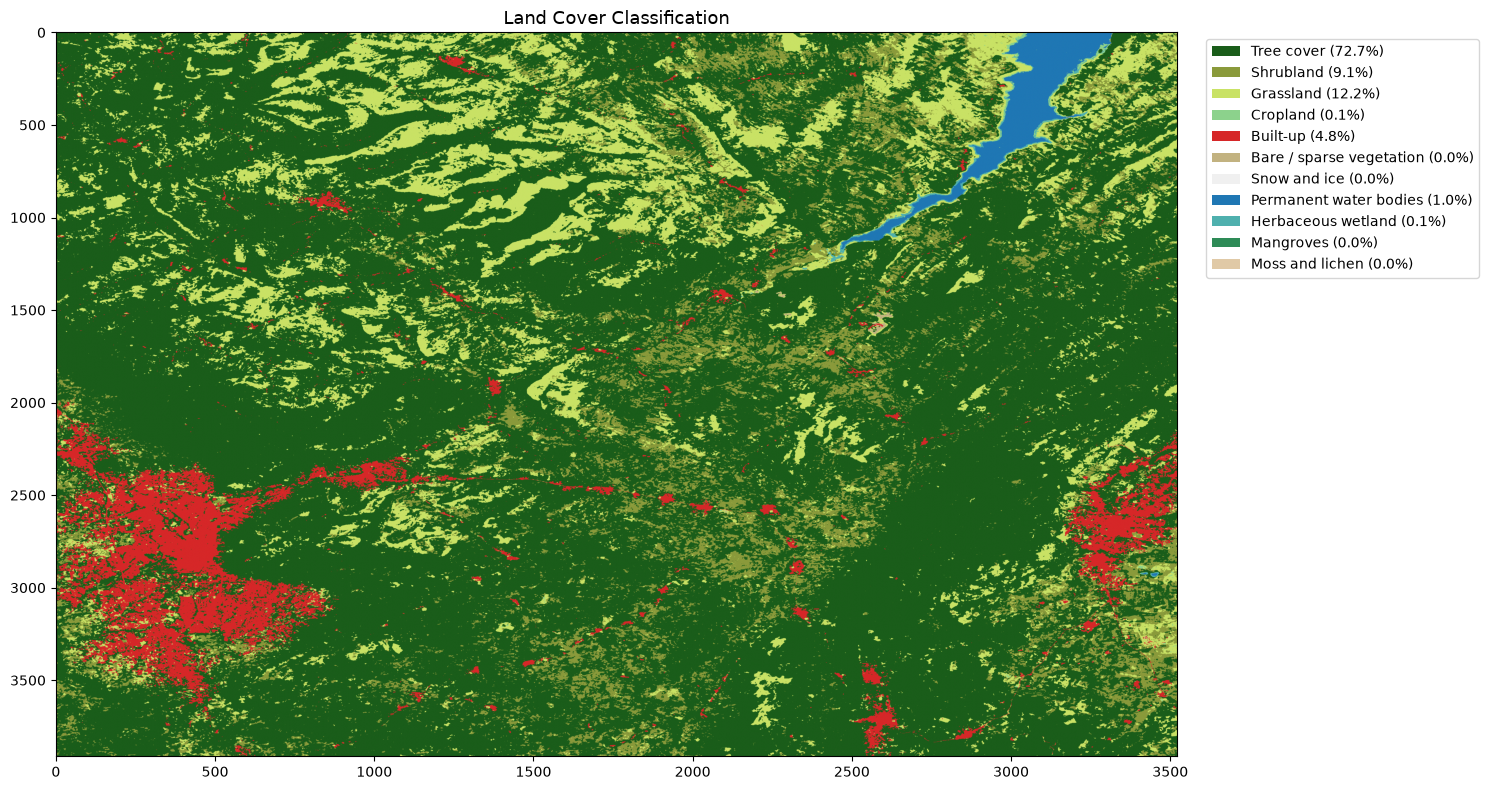

In [19]:
from pygeofetch.viz import Plotter
import matplotlib.pyplot as plt
import rasterio

plotter = Plotter()

WORLDCOVER_LABELS = {
    10: "Tree cover",
    20: "Shrubland",
    30: "Grassland",
    40: "Cropland",
    50: "Built-up",
    60: "Bare / sparse vegetation",
    70: "Snow and ice",
    80: "Permanent water bodies",
    90: "Herbaceous wetland",
    95: "Mangroves",
    100: "Moss and lichen",
}

WORLDCOVER_COLORS = {
    10: "#1a5d1a",   # forest green — tree cover
    20: "#8a9a3b",   # olive/dark khaki — shrubland (distinct from grassland & trees)
    30: "#c9e265",   # light yellow-green — grassland
    40: "#8cd28c",   # tan — cropland
    50: "#d62728",   # red — built-up
    60: "#c2b280",   # sandy grey-tan — bare/sparse vegetation
    70: "#f0f0f0",   # near-white — snow and ice
    80: "#1f77b4",   # blue — permanent water bodies
    90: "#4fb0ae",   # teal — herbaceous wetland (between water-blue and mangrove-green)
    95: "#2e8b57",   # sea green — mangroves (greener/wetter than tree cover)
    100: "#e0c9a6",  # pale tan — moss and lichen (lighter than bare ground)
}
# Read the actual classified array from lc.tif — not `ready`
with rasterio.open("./data/lc.tif") as src:
    class_arr = src.read(1)   # single band of integer class codes

plotter = Plotter(figsize=(15,8))
plotter.plot_classification(
    class_arr,
    class_labels=WORLDCOVER_LABELS,
    class_colors=WORLDCOVER_COLORS,
    title="Land Cover Classification",
    # output="./data/lc_plot.png",
)
plt.show()

In [1]:
import pygeovision as pgv
from pathlib import Path

client = pgv.PyGeoVision()

BOUNDARY_PATH = "./data/accra_boundary.geojson"
BANDS = ["B02", "B03", "B04", "B08", "B11", "B12"]
COMMON_CRS = "EPSG:32630"

aoi = client.boundary(
    "Accra Metropolitan District, Greater Accra Region, Ghana",
    output_path=BOUNDARY_PATH,
    reference_area_km2=139.0,
    raise_on_mismatch=False,
)
print(aoi.summary())

# 1. Search wide — enough candidates for select_covering_scenes to choose from
results = client.search(
    bbox=aoi.bbox,
    date_range=("2024-01-01", "2024-04-30"),
    providers=["element84"],
    cloud_cover_max=15,
    sort_by="cloud_cover",
    use_cache=False,
    max_results=50,
)
if not results:
    raise RuntimeError("No scenes found for Accra bbox — widen date_range or cloud_cover_max.")

# 2. Pick the fewest, lowest-cloud scenes that together cover the whole AOI
selected = client.select_covering_scenes(results, aoi.bbox, max_scenes=6)
print(f"Selected {len(selected)}/{len(results)} scenes to cover the AOI")

# 3. Download all selected scenes — bands= now requires the fetch.py patch
#    (filtering satellite_data.assets via resolve_band_keys) to actually
#    restrict what's downloaded, not just what's read afterward.
downloads = client.download(
    selected, output_dir="./data_new/tiles",
    bands=BANDS,
)
failed = [d for d in downloads if not d.success or not d.path]
for f in failed:
    print(f"  FAILED: {f.scene_id} — {f.error or 'no error message'}")
succeeded = [d for d in downloads if d.success and d.path]
if not succeeded:
    raise RuntimeError("All scene downloads failed — see errors above.")
print(f"{len(succeeded)}/{len(downloads)} scenes downloaded successfully")

# 4. Stack each scene's bands into one real multi-band GeoTIFF BEFORE
#    reprojecting. d.path is a scene directory (e.g. data_new/tiles/aws_earth/),
#    not a file — handing a directory straight to preprocess_reproject()
#    silently resolves to whichever single-band file it finds first
#    alphabetically (AOT.tif), producing a 1-band mosaic of aerosol data_new
#    instead of real reflectance bands. This was the cause of last run's
#    "72.7% tree cover, river" garbage result.
stacked_paths = []
for d in succeeded:
    stacked = client.preprocess.stack_from_dir(
        scene_dir=str(d.path),
        band_names=BANDS,
        output_path=f"./data_new/stacks/{d.scene_id}_stack.tif",
    )
    stacked_paths.append(stacked)
    print(f"  Stacked {d.scene_id} → {stacked}")

# 5. Reproject every stacked tile to one common CRS before mosaicking
#    (Accra sits close to the 30N/31N UTM boundary — tiles can differ)
reprojected_paths = [
    client._pgf_bridge.preprocess_reproject(p, crs=COMMON_CRS)
    for p in stacked_paths
]

# 6. Sanity check before mosaicking — confirm every tile has the full
#    band count. If this fails, one of the downloads/stacks silently
#    dropped a band and needs fixing before mosaicking, not after.
import rasterio
for p in reprojected_paths:
    with rasterio.open(p) as src:
        if src.count != len(BANDS):
            raise RuntimeError(
                f"{p} has {src.count} band(s), expected {len(BANDS)} "
                f"({BANDS}) — check the download/stack step for this scene "
                f"before mosaicking."
            )
print(f"All {len(reprojected_paths)} tiles confirmed at {len(BANDS)} bands each")

# 7. Mosaic via the public, validated Preprocessor.mosaic()
mosaic_path = client.preprocess.mosaic(
    reprojected_paths,
    output_path="./data_new/accra_mosaic.tif",
    method="first",
)
print(f"Mosaic written to: {mosaic_path}")

# 8. Confirm the mosaic itself has the full band count before proceeding
with rasterio.open(mosaic_path) as src:
    print(f"Mosaic: {src.count} band(s), {src.width}x{src.height} px, CRS={src.crs}")
    if src.count != len(BANDS):
        raise RuntimeError(
            f"Mosaic has {src.count} band(s), expected {len(BANDS)} — "
            f"do not proceed to prepare_for_ai/land_cover with this file."
        )

# 9. Prepare the mosaic for AI, clipped to the real boundary polygon
ready = client.prepare_for_ai(
    mosaic_path,
    model_type="foundation",
    output_path="./data_new/ready.tif",
    clip_geojson=BOUNDARY_PATH,
)

client.classification.land_cover(ready, output_path="./data_new/lc.tif")

01:43:47 INFO [      engine] PyGeoFetch ready


2026-07-30 01:43:47,611 [INFO] pygeofetch.core.engine: PyGeoFetch ready


01:43:47 INFO [      engine] PyGeoFetch ready


2026-07-30 01:43:47,614 [INFO] pygeofetch.core.engine: PyGeoFetch ready
2026-07-30 01:43:47,616 [INFO] pygeovision.data.pgf_bridge: PyGeoFetch v1.0 Python API active — using native search/download
2026-07-30 01:43:47,616 [INFO] pygeovision.data.pgf_bridge: PyGeoFetch v2.0 processing engine detected — using native preprocessing


2026-07-30 01:43:48,882 [WARNING] pygeovision.data.boundary: Fetched boundary area (23.7 km²) deviates 83% from the known reference (139.0 km²) for 'Accra Metropolitan District, Greater Accra Region, Ghana'. Two likely causes: (1) the query resolved to the wrong OSM entity — check osm_type='relation', category='boundary', display_name='Accra Metropolitan District, Greater Accra Region, Ghana' against what you expect; or (2) this is the *right* entity, but OpenStreetMap's community-digitized boundary for it is measurably smaller/larger than the official statistic — a real, known limitation for many regions (especially outside Europe/North America), not necessarily an error. Inspect the geometry yourself (output_path, if given) before deciding whether to proceed with raise_on_mismatch=False or a wider tolerance.
2026-07-30 01:43:48,884 [INFO] pygeovision.data.fetch: Searching 1 provider(s) [aws_earth] | bbox=(-0.255486, 5.522781, -0.200876, 5.599425) | 2024-01-01→2024-04-30 | cloud≤15%


...

01:43:51 INFO [  downloader]   ✓ S2B_30NZM_20240313_0_L2A                        186.6 MB    0.0s


✓ S2A_30NYM_20240301_0_L2A: 100%|██████████| 187M/187M [00:00<00:00, 1.11GB/s]2026-07-30 01:43:51,917 [INFO] pygeofetch.core.downloader:   ✓ S2B_30NZM_20240313_0_L2A                        186.6 MB    0.0s




⬇ 6 scenes  →  data_new/tiles  ████████▎   5/6  [00:00]



















⬇ 6 scenes  →  data_new/tiles  ██████████  6/6  [00:00]

  [████████████████████████████████████████] 6/6 (100%) | 1119.3 MB



  ──────────────────────────────────────────────────
  ✅ Download complete: 6/6 scenes
  📦 Total size: 1119.3 MB
  ⏱️  Duration: 0.5 seconds (0.0 minutes)
  ──────────────────────────────────────────────────

6/6 scenes downloaded successfully


FileNotFoundError: No .tif files found in data_new/tiles/aws_earth/AOT.tif. Check that the scene was downloaded and the pattern is correct.

In [2]:
from pathlib import Path

for d in succeeded:
    scene_dir = Path(d.path).parent
    print(f"\n{d.scene_id}:")
    print(f"  d.path = {d.path}")
    if scene_dir.exists():
        files = sorted(scene_dir.glob("*"))
        print(f"  Files in {scene_dir}:")
        for f in files:
            print(f"    {f.name}  ({f.stat().st_size / 1024 / 1024:.1f} MB)")
    else:
        print(f"  Directory {scene_dir} does not exist!")


S2B_30NYM_20240313_0_L2A:
  d.path = data_new/tiles/aws_earth/AOT.tif
  Files in data_new/tiles/aws_earth:
    AOT.tif  (0.3 MB)
    B01.tif  (0.4 MB)
    B02.tif  (108.7 MB)
    B03.tif  (11.0 MB)
    B04.tif  (15.9 MB)
    B05.tif  (8.4 MB)
    B06.tif  (8.5 MB)
    B07.tif  (8.6 MB)
    B08.tif  (11.6 MB)
    B09.tif  (0.4 MB)
    B11.tif  (3.5 MB)
    B12.tif  (4.3 MB)
    B8A.tif  (4.4 MB)
    SCL.tif  (0.1 MB)
    WVP.tif  (0.3 MB)

S2B_30NYM_20240303_0_L2A:
  d.path = data_new/tiles/aws_earth/AOT.tif
  Files in data_new/tiles/aws_earth:
    AOT.tif  (0.3 MB)
    B01.tif  (0.4 MB)
    B02.tif  (108.7 MB)
    B03.tif  (11.0 MB)
    B04.tif  (15.9 MB)
    B05.tif  (8.4 MB)
    B06.tif  (8.5 MB)
    B07.tif  (8.6 MB)
    B08.tif  (11.6 MB)
    B09.tif  (0.4 MB)
    B11.tif  (3.5 MB)
    B12.tif  (4.3 MB)
    B8A.tif  (4.4 MB)
    SCL.tif  (0.1 MB)
    WVP.tif  (0.3 MB)

S2B_30NZM_20240303_0_L2A:
  d.path = data_new/tiles/aws_earth/AOT.tif
  Files in data_new/tiles/aws_earth:
    AO

In [ ]:
"""
Standalone processing pipeline: assumes scenes are already downloaded to disk,
each in its own scene-ID-scoped subdirectory. Runs stack → reproject → mosaic
→ prepare_for_ai → land_cover.

Run this after client.download(...) has completed successfully with the
per-scene-destination fix applied (each scene in its own folder, not sharing
filenames with other scenes).
"""
import pygeovision as pgv
from pathlib import Path
import rasterio

client = pgv.PyGeoVision()

BOUNDARY_PATH = "./data/accra_boundary.geojson"
BANDS = ["B02", "B03", "B04", "B08", "B11", "B12"]
COMMON_CRS = "EPSG:32630"
TILES_ROOT = Path("./data_new/tiles")

# ── 1. Discover per-scene directories already on disk ──────────────────────
# Each scene is expected to be under its own subdirectory (scene_id), per the
# per-scene-destination download fix. Adjust the glob pattern if your actual
# on-disk layout differs (e.g. TILES_ROOT/{scene_id}/aws_earth/*.tif).
scene_dirs = sorted(d for d in TILES_ROOT.iterdir() if d.is_dir())
if not scene_dirs:
    raise RuntimeError(
        f"No scene subdirectories found under {TILES_ROOT}. "
        "Confirm the download step completed and used per-scene destinations."
    )
print(f"Found {len(scene_dirs)} scene directories under {TILES_ROOT}:")
for d in scene_dirs:
    print(f"  {d.name}")

# ── 2. Sanity check: every scene directory has the full band set, and no
#      two scenes are secretly pointing at the same files (the exact bug
#      that corrupted the last run when all scenes shared one directory) ──
seen_file_signatures = {}
for scene_dir in scene_dirs:
    missing = []
    for band in BANDS:
        matches = list(scene_dir.rglob(f"*{band}*.tif"))
        if not matches:
            missing.append(band)
    if missing:
        raise RuntimeError(
            f"{scene_dir.name} is missing band(s) {missing}. "
            f"Files present: {[f.name for f in scene_dir.rglob('*.tif')]}"
        )
    # Fingerprint by (file size, mtime) of B02 as a cheap duplicate-detector —
    # if two "different" scenes have identical B02 size+mtime, they're
    # probably the same underlying file (the overwrite bug), not two real tiles.
    b02 = next(scene_dir.rglob("*B02*.tif"))
    sig = (b02.stat().st_size, b02.stat().st_mtime)
    if sig in seen_file_signatures:
        raise RuntimeError(
            f"{scene_dir.name}'s B02.tif looks identical (size+mtime) to "
            f"{seen_file_signatures[sig]}'s — these may be the same file "
            f"due to the directory-overwrite bug. Re-download with per-scene "
            f"destinations before proceeding."
        )
    seen_file_signatures[sig] = scene_dir.name

print(f"All {len(scene_dirs)} scenes verified: full band set, no duplicate/overwritten files.")

# ── 3. Stack each scene's bands into one real multi-band GeoTIFF ───────────
stacked_paths = []
for scene_dir in scene_dirs:
    stacked = client.preprocess.stack_from_dir(
        scene_dir=str(scene_dir),
        band_names=BANDS,
        output_path=f"./data_new/stacks/{scene_dir.name}_stack.tif",
    )
    stacked_paths.append(stacked)
    print(f"  Stacked {scene_dir.name} → {stacked}")

# ── 4. Reproject every stacked tile to one common CRS before mosaicking ────
reprojected_paths = [
    client._pgf_bridge.preprocess_reproject(p, crs=COMMON_CRS)
    for p in stacked_paths
]

# ── 5. Confirm every tile has the full band count before mosaicking ────────
for p in reprojected_paths:
    with rasterio.open(p) as src:
        if src.count != len(BANDS):
            raise RuntimeError(
                f"{p} has {src.count} band(s), expected {len(BANDS)} ({BANDS}) — "
                f"check the download/stack step for this scene before mosaicking."
            )
print(f"All {len(reprojected_paths)} tiles confirmed at {len(BANDS)} bands each")

# ── 6. Mosaic via the public, validated Preprocessor.mosaic() ──────────────
mosaic_path = client.preprocess.mosaic(
    reprojected_paths,
    output_path="./data_new/accra_mosaic.tif",
    method="first",
)
print(f"Mosaic written to: {mosaic_path}")

# ── 7. Confirm the mosaic itself has the full band count ───────────────────
with rasterio.open(mosaic_path) as src:
    print(f"Mosaic: {src.count} band(s), {src.width}x{src.height} px, CRS={src.crs}")
    if src.count != len(BANDS):
        raise RuntimeError(
            f"Mosaic has {src.count} band(s), expected {len(BANDS)} — "
            f"do not proceed to prepare_for_ai/land_cover with this file."
        )

# ── 8. Prepare the mosaic for AI, clipped to the real boundary polygon ─────
ready = client.prepare_for_ai(
    mosaic_path,
    model_type="foundation",
    output_path="./data_new/ready.tif",
    clip_geojson=BOUNDARY_PATH,
)

client.classification.land_cover(ready, output_path="./data_new/lc.tif")
print("Land cover classification complete → ./data_new/lc.tif")

02:03:24 INFO [      engine] PyGeoFetch ready


2026-07-30 02:03:24,433 [INFO] pygeofetch.core.engine: PyGeoFetch ready


02:03:24 INFO [      engine] PyGeoFetch ready


2026-07-30 02:03:24,438 [INFO] pygeofetch.core.engine: PyGeoFetch ready
2026-07-30 02:03:24,439 [INFO] pygeovision.data.pgf_bridge: PyGeoFetch v1.0 Python API active — using native search/download
2026-07-30 02:03:24,440 [INFO] pygeovision.data.pgf_bridge: PyGeoFetch v2.0 processing engine detected — using native preprocessing


Found 1 scene directories under data_new/tiles:
  aws_earth
All 1 scenes verified: full band set, no duplicate/overwritten files.


2026-07-30 02:03:38,482 [INFO] pygeovision.preprocess.core: Stacked 6 bands → ./data_new/stacks/aws_earth_stack.tif


  Stacked aws_earth → ./data_new/stacks/aws_earth_stack.tif
02:04:02 INFO [preprocessor] Reprojected → EPSG:32630 → data_new/stacks/aws_earth_stack_reproj_EPSG_32630.tif


2026-07-30 02:04:02,913 [INFO] pygeofetch.processing.preprocessor: Reprojected → EPSG:32630 → data_new/stacks/aws_earth_stack_reproj_EPSG_32630.tif


All 1 tiles confirmed at 6 bands each
Mosaic written to: data_new/stacks/aws_earth_stack_reproj_EPSG_32630.tif
Mosaic: 6 band(s), 10980x10980 px, CRS=EPSG:32630
